# Week 4 - Module 2: EDA & Feature Engineering

This notebook follows the Module 2 brief more closely using the synthetic telemetry file `data/telemetry_samples.csv`.

Goals:
- load telemetry and ratings data
- visualize the distribution of ratings
- create derived features such as `avg_speed`, `max_accel`, `hard_brake_count`, `stop_count`, `speed_variance`, `trip_time_of_day`, and `distance_per_min`
- aggregate features at the trip and driver levels
- generate key visuals such as a rating histogram, boxplots by `hard_brake_count`, and a correlation heatmap

Note: the base synthetic file contains only `driver_id`, `speed`, `hard_brake`, and `rating`, so this notebook creates pseudo `trip_id` and `timestamp` fields to support the feature-engineering tasks.

In [2]:
!pip install pandas numpy matplotlib seaborn

zsh:1: command not found: pip


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = Path(r"/Users/ayet_dub/Documents/Codex/2026-05-11/files-mentioned-by-the-user-test")
telemetry_path = BASE_DIR / "data" / "telemetry_samples.csv"
df = pd.read_csv(telemetry_path)

df.head()

,driver_id,speed,hard_brake,rating
0,D038,32.594915,0,5
1,D028,24.893896,0,4
2,D014,54.265612,0,3
3,D042,39.504299,0,4
4,D007,42.087596,0,5


In [4]:
# Create pseudo trip and time fields so the synthetic telemetry can support Module 2 tasks.
trip_size = 20
sample_interval_sec = 30
base_time = pd.Timestamp("2026-05-01 06:00:00")

df = df.copy().reset_index(drop=True)
df["row_id"] = np.arange(len(df))
df["trip_seq"] = df["row_id"] // trip_size
df["trip_id"] = "TRIP-" + (df["trip_seq"] + 1).astype(str).str.zfill(3)
df["sample_in_trip"] = df.groupby("trip_id").cumcount()
df["timestamp"] = base_time + pd.to_timedelta(df["trip_seq"] * 37, unit="m") + pd.to_timedelta(df["sample_in_trip"] * sample_interval_sec, unit="s")

df["speed_m_s"] = df["speed"] * (1000 / 3600)
df["prev_speed_m_s"] = df.groupby("trip_id")["speed_m_s"].shift(1)
df["accel_m_s2"] = ((df["speed_m_s"] - df["prev_speed_m_s"]) / sample_interval_sec).fillna(0)
df["distance_step_km"] = df["speed_m_s"] * sample_interval_sec / 1000
df["stop_flag"] = (df["speed"] < 5).astype(int)

hour = df["timestamp"].dt.hour
df["trip_time_of_day"] = np.select(
    [
        hour.between(5, 11),
        hour.between(12, 16),
        hour.between(17, 20),
    ],
    ["morning", "afternoon", "evening"],
    default="night",
)

df[["driver_id", "trip_id", "timestamp", "speed", "speed_m_s", "accel_m_s2", "hard_brake", "rating"]].head(10)

,driver_id,trip_id,timestamp,speed,speed_m_s,accel_m_s2,hard_brake,rating
0,D038,TRIP-001,2026-05-01 06:00:00,32.594915,9.054143,0.000000,0,5
1,D028,TRIP-001,2026-05-01 06:00:30,24.893896,6.914971,-0.071306,0,4
2,D014,TRIP-001,2026-05-01 06:01:00,54.265612,15.073781,0.271960,0,3
3,D042,TRIP-001,2026-05-01 06:01:30,39.504299,10.973416,-0.136679,0,4
4,D007,TRIP-001,2026-05-01 06:02:00,42.087596,11.690999,0.023919,0,5
5,D020,TRIP-001,2026-05-01 06:02:30,50.894463,14.137351,0.081545,0,4
6,D038,TRIP-001,2026-05-01 06:03:00,39.894513,11.081809,-0.101851,0,4
7,D018,TRIP-001,2026-05-01 06:03:30,45.416934,12.615815,0.051134,0,4
8,D022,TRIP-001,2026-05-01 06:04:00,49.790219,13.830617,0.040493,0,4
9,D010,TRIP-001,2026-05-01 06:04:30,46.801071,13.000298,-0.027677,0,4


In [5]:
print("Shape:", df.shape)
print("Drivers:", df["driver_id"].nunique())
print("Trips:", df["trip_id"].nunique())
print("Ratings distribution:\n", df["rating"].value_counts().sort_index())

Shape: (1000, 15)
Drivers: 50
Trips: 50
Ratings distribution:
 rating
2     13
3    138
4    570
5    279
Name: count, dtype: int64


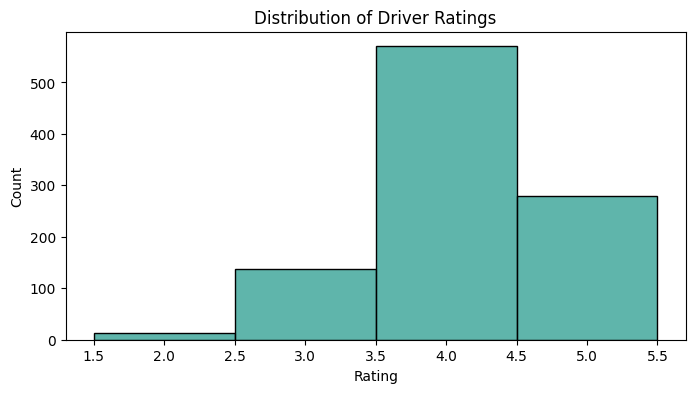

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(df["rating"], bins=np.arange(0.5, 6.5, 1), discrete=True, color="#2a9d8f")
plt.title("Distribution of Driver Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [7]:
# Aggregate per trip with the features requested in the module brief.
trip_agg = (
    df.groupby(["driver_id", "trip_id"], as_index=False)
    .agg(
        avg_speed=("speed", "mean"),
        max_accel=("accel_m_s2", "max"),
        hard_brake_count=("hard_brake", "sum"),
        stop_count=("stop_flag", "sum"),
        speed_variance=("speed", "var"),
        trip_time_of_day=("trip_time_of_day", lambda s: s.mode().iat[0]),
        distance_km=("distance_step_km", "sum"),
        trip_duration_min=("sample_in_trip", lambda s: ((s.max() + 1) * sample_interval_sec) / 60),
        rating_mean=("rating", "mean"),
    )
)

trip_agg["speed_variance"] = trip_agg["speed_variance"].fillna(0)
trip_agg["distance_per_min"] = trip_agg["distance_km"] / trip_agg["trip_duration_min"]
trip_agg = trip_agg.sort_values(["driver_id", "trip_id"]).reset_index(drop=True)

trip_agg.head()

,driver_id,trip_id,avg_speed,max_accel,hard_brake_count,stop_count,speed_variance,trip_time_of_day,distance_km,trip_duration_min,rating_mean,distance_per_min
0,D000,TRIP-005,43.917080,0.048711,0,0,0.000000,morning,0.365976,9.0,4.0,0.040664
1,D000,TRIP-006,36.773990,0.136926,0,0,0.000000,morning,0.306450,1.5,5.0,0.204300
2,D000,TRIP-007,38.387393,0.051832,0,0,91.557123,morning,0.639790,10.0,5.0,0.063979
3,D000,TRIP-010,27.309625,-0.086858,0,0,0.000000,morning,0.227580,3.0,4.0,0.075860
4,D000,TRIP-012,31.849097,-0.058949,0,0,0.000000,afternoon,0.265409,2.0,4.0,0.132705


In [8]:
# Exact feature-engineering snippet style from the module guide.
driver_agg = df.groupby("driver_id").agg({"speed": ["mean", "std"], "hard_brake": "sum", "rating": "mean"}).reset_index()
driver_agg.columns = ["driver_id", "speed_mean", "speed_std", "hard_brake_sum", "rating_mean"]

# Expanded per-driver feature table.
driver_features = (
    trip_agg.groupby("driver_id", as_index=False)
    .agg(
        trips=("trip_id", "nunique"),
        avg_speed=("avg_speed", "mean"),
        avg_max_accel=("max_accel", "mean"),
        hard_brake_count=("hard_brake_count", "sum"),
        stop_count=("stop_count", "sum"),
        avg_speed_variance=("speed_variance", "mean"),
        avg_distance_per_min=("distance_per_min", "mean"),
        rating_mean=("rating_mean", "mean"),
    )
)

driver_agg.head(), driver_features.head()

(  driver_id  speed_mean  speed_std  hard_brake_sum  rating_mean
 0      D000   40.717936  13.326424               1     4.291667
 1      D001   40.409596  14.954360               0     4.047619
 2      D002   44.096943  13.029549               2     4.136364
 3      D003   44.624196  11.365221               0     4.187500
 4      D004   40.774038  10.953109               2     4.086957,
   driver_id  trips  avg_speed  avg_max_accel  hard_brake_count  stop_count  \
 0      D000     20  41.418451       0.012919                 1           0   
 1      D001     18  40.359563      -0.028849                 0           0   
 2      D002     19  44.457567       0.091968                 2           0   
 3      D003     14  44.716637       0.050625                 0           0   
 4      D004     16  39.759612       0.010176                 2           0   
 
    avg_speed_variance  avg_distance_per_min  rating_mean  
 0           21.864289              0.112489     4.241667  
 1           

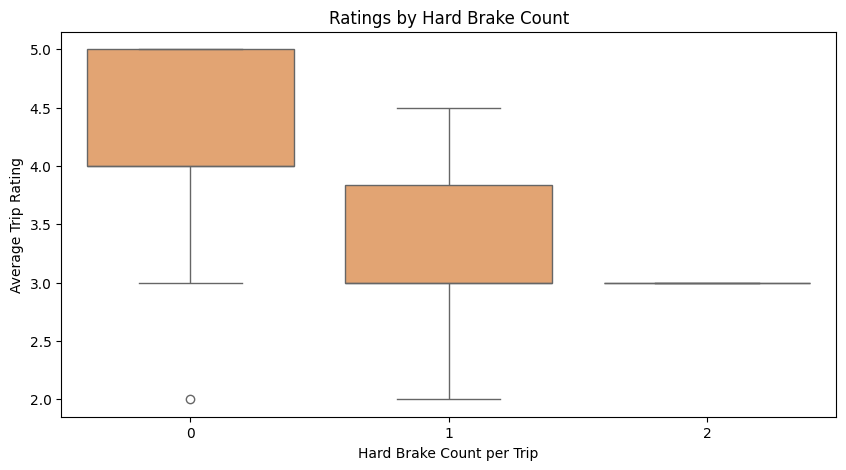

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=trip_agg, x="hard_brake_count", y="rating_mean", color="#f4a261")
plt.title("Ratings by Hard Brake Count")
plt.xlabel("Hard Brake Count per Trip")
plt.ylabel("Average Trip Rating")
plt.show()

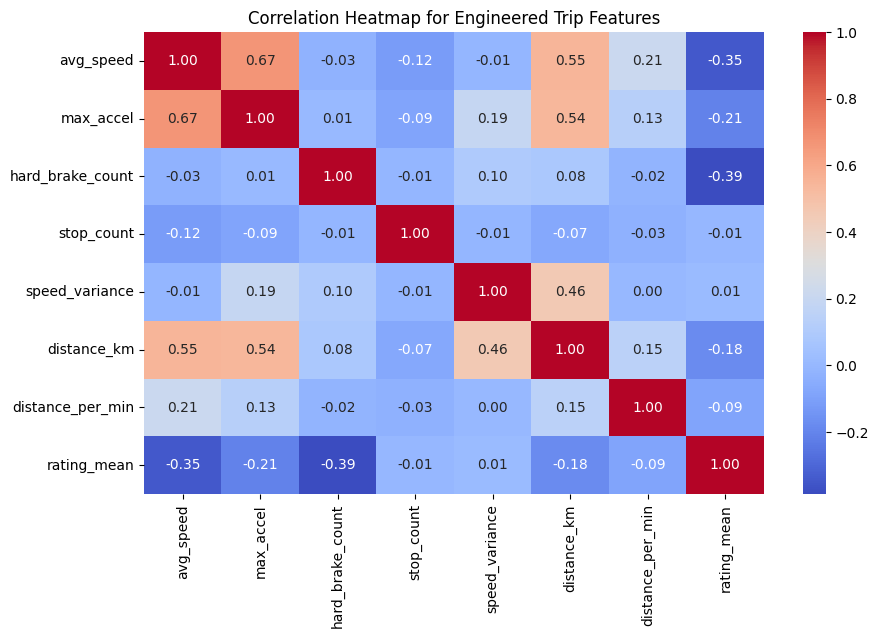

In [10]:
corr_cols = [
    "avg_speed",
    "max_accel",
    "hard_brake_count",
    "stop_count",
    "speed_variance",
    "distance_km",
    "distance_per_min",
    "rating_mean",
]

plt.figure(figsize=(10, 6))
sns.heatmap(trip_agg[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap for Engineered Trip Features")
plt.show()

In [11]:
trip_out = BASE_DIR / "data" / "module2_trip_features.csv"
driver_out = BASE_DIR / "data" / "module2_driver_features.csv"
trip_agg.to_csv(trip_out, index=False)
driver_features.to_csv(driver_out, index=False)

print("Saved:", trip_out)
print("Saved:", driver_out)

Saved: /Users/ayet_dub/Documents/Codex/2026-05-11/files-mentioned-by-the-user-test/data/module2_trip_features.csv
Saved: /Users/ayet_dub/Documents/Codex/2026-05-11/files-mentioned-by-the-user-test/data/module2_driver_features.csv


#

This notebook now covers the requested Module 2 workflow:
- loaded synthetic telemetry and ratings
- visualized rating distribution
- engineered trip-level and driver-level features
- created boxplots by `hard_brake_count`
- produced a correlation heatmap for modeling features

Suggested next step: use `data/module2_trip_features.csv` and `data/module2_driver_features.csv` as inputs for Module 3 regression and Module 5 violation detection experiments.